# 03 · Embeddings y similitudes con el Tesauro COM-B
**Proyecto:** Marco COM-B en la esfera pública — análisis de tweets en español
**Equivalente original:** `4_busqueda_ciencia.ipynb`

---

### Diferencias con el paper y con las replicaciones anteriores

| Aspecto | Paper (columnas de opinión) | Este notebook (tweets) |
|---|---|---|
| Unidad de análisis | Chunks de 150 palabras | Tweet completo (`texto_chunk`) |
| Tesauro | UNESCO — Ciencia (.txt) | **COM-B — 6 subcomponentes (.txt)** |
| Similitud por documento | Promedio de embeddings de sus chunks | Directo (tweet = 1 chunk = 1 doc) |
| Modelo | `google/embeddinggemma-300M` (HF login) | `paraphrase-multilingual-mpnet-base-v2` (público) |

**Metodología:** réplica exacta de `utils_semantic_search.py` de Karen,
cambiando el dominio del tesauro: en lugar de detectar *temas* (salud) o
*comportamientos protectores*, detecta los **componentes del modelo COM-B**
(Capacidad, Oportunidad, Motivación) expresados en el discurso.

**Entradas:**
- `resultadosCOMB/chunks.parquet`

**Salidas:**
- `resultadosCOMB/tweet_embeddings.npy`
- `resultadosCOMB/similitudes_chunks.parquet` / `.xlsx`
- `resultadosCOMB/similitudes_docs.parquet` / `.xlsx`
- `resultadosCOMB/comb_etiquetados_binario.parquet`
- `resultadosCOMB/comb_tweets.parquet`


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

# Modelo de embeddings
# El paper usa google/embeddinggemma-300M (requiere login en HuggingFace).
# Usamos paraphrase-multilingual-mpnet-base-v2: publico, ~278M params,
# excelente en similitud semantica en espanol, sin necesidad de login.
MODEL_ID   = 'paraphrase-multilingual-mpnet-base-v2'
BATCH_SIZE = 128
RELOAD     = False   # True para forzar recalculo de embeddings

# Umbral provisional (se optimiza en el notebook 04)
UMBRAL_PROVISIONAL = 0.47

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')
print(f'  Modelo         : {MODEL_ID}')
print(f'  RELOAD         : {RELOAD}')

[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB
  Modelo         : paraphrase-multilingual-mpnet-base-v2
  RELOAD         : False


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a:
#   chunks_df = pd.read_parquet('../data/processed/chunks.parquet')
#   corpus    = pd.read_excel('../data/processed/corpus_cleaned.xlsx')
# ============================================================
import pandas as pd
import numpy as np
import glob
import os
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo : {device}')

# Cargar chunks (salida del notebook 01)
chunks_df = pd.read_parquet(DATA_PROCESSED / 'chunks.parquet')
print(f'Chunks cargados : {len(chunks_df):,}')
print(f'Columnas        : {list(chunks_df.columns)}')
chunks_df.head(3)

Dispositivo : cuda
Chunks cargados : 151,424
Columnas        : ['id_doc', 'chunk_id', 'num_chunk', 'autor_doc', 'nombre_autor_doc', 'fecha_doc', 'date_doc', 'anio', 'mes', 'anio_mes', 'Sentimiento', 'Polaridad', 'Entidad', 'texto_chunk', 'n_palabras_chunk']


,id_doc,chunk_id,num_chunk,autor_doc,nombre_autor_doc,fecha_doc,date_doc,anio,mes,anio_mes,Sentimiento,Polaridad,Entidad,texto_chunk,n_palabras_chunk
0,1,1_1,1,@treporta,Telemetro Reporta,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Neutra,"Noticias locales, nacionales o globales",VDEO Reos que no están contagiados con COVID19...,15
1,2,2_1,1,@annytak21,ANNA KAROLYNNA,2020-06-03,2020-06-03 18:56:24,2020,6,2020-06,otro,Negativa,Sin descripción,ya se enteraron de la muerte supestamente por ...,24
2,3,3_1,1,@ferumapress,Fernando Umaña Mejía,2020-06-03,2020-06-03 18:56:17,2020,6,2020-06,otro,Negativa,"Noticias locales, nacionales o globales",El calvario de una familia en Cali por su mamá...,14


## 2 · Tesauro COM-B
En el paper Karen carga las subcategorías desde archivos `.txt` en una carpeta
(`uss.cargar_subcategorias(dir_tesauro, model)`). Cada archivo tiene un término
por línea; la función los concatena en una frase y genera un único embedding.

Aquí el tesauro no proviene de la UNESCO sino del **modelo COM-B**
(Michie, van Stralen & West, 2011): los 6 subcomponentes que explican el
comportamiento — Capacidad (física / psicológica), Oportunidad (física / social)
y Motivación (reflexiva / automática). Las palabras clave y frases de ejemplo
provienen del documento *"Listado de palabras clave del COM-B"* compartido por
una magister en estudios del comportamiento, con ejemplos en contexto de pandemia.


In [3]:
# ============================================================
# CELL 2 — CREAR ARCHIVOS .TXT DEL TESAURO COM-B
# Replica la estructura que usa cargar_subcategorias():
# un archivo .txt por subcomponente, un termino/frase por linea.
#
# Fuente: "Listado de palabras clave del COM-B", documento elaborado
# por una magister en estudios del comportamiento, basado en
# Michie, van Stralen & West (2011) — doi:10.1186/1748-5908-6-42.
# Cada subcomponente agrupa las palabras clave de sus subcategorias
# + los ejemplos en contexto de pandemia del documento.
# ============================================================

DIR_TESAURO = DATA_PROCESSED / 'Tesauro_COMB'
DIR_TESAURO.mkdir(parents=True, exist_ok=True)

TESAURO_COMB = {
    # =========================================================
    # 1. MOTIVACION
    # =========================================================
    # Motivacion reflexiva: procesos conscientes (creencias,
    # evaluaciones, intenciones, metas, reglas, identidad, negacion)
    'COMB_Motivacion_reflexiva': [
        # Intenciones
        'quiero', 'voy a', 'planeo', 'decido', 'me propongo',
        'tengo la intención', 'pienso hacer',
        'quiero vacunarme', 'voy a cuidarme', 'planeo quedarme en casa',
        'decido quedarme en casa', 'decido usar tapabocas',
        # Creencias y actitudes
        'creo que', 'considero que', 'me parece', 'opino',
        'estoy convencido', 'es importante', 'vale la pena',
        'creo que el virus existe', 'considero que la vacuna es segura',
        'opino que las medidas sirven', 'creo que el virus es real',
        'pienso que hay que cuidarse',
        # Evaluacion de consecuencias
        'me beneficia', 'sirve para', 'tiene sentido', 'es mejor',
        'prefiero', 'no vale la pena', 'me perjudica',
        'me puedo contagiar', 'el riesgo es real', 'no vale la pena el riesgo',
        'me puede matar', 'es peligroso contagiarse', 'me puede dejar secuelas',
        # Metas y compromisos
        'meta', 'objetivo', 'propósito', 'compromiso', 'logro',
        'alcanzar', 'conseguir',
        'proteger a mi familia', 'no contagiarme', 'que la pandemia termine',
        'volver a la normalidad',
        # Reglas
        'debo', 'debería', 'es mi responsabilidad', 'es correcto',
        'me siento en el deber',
        'debo cuidarme', 'es mi responsabilidad cuidar a otros',
        'es lo correcto usar tapabocas', 'me siento en el deber de aislarme',
        # Identidad
        'me identifico con', 'soy el tipo de persona que',
        'forma parte de mis valores',
        'soy de las personas que se cuidan', 'me importa cuidar a otros',
        # Negacion
        'no tiene sentido', 'no lo veo necesario', 'no creo que funcione',
        'no estoy de acuerdo',
        'no creo en el virus', 'los números son falsos',
        'nos están manipulando', 'es una conspiración', 'nos engañan',
        'la vacuna es un experimento',
    ],

    # Motivacion automatica: procesos emocionales e impulsivos
    # (emociones, habitos, deseos, urgencias)
    'COMB_Motivacion_automatica': [
        # Emociones positivas
        'me encanta', 'amo', 'disfruto', 'me emociona', 'me alegra',
        'feliz', 'entusiasmo',
        'me alegra que por fin hay vacuna',
        'qué felicidad porque ya casi podemos salir',
        'me emociona ver a mi familia', 'feliz de estar sano',
        # Emociones negativas
        'odio', 'miedo', 'angustia', 'asco', 'me da rabia',
        'frustración', 'tristeza', 'ansiedad',
        'miedo al contagio', 'me da miedo salir', 'no aguanto más',
        'cansancio pandémico', 'ya no puedo', 'indignación', 'rabia',
        'esto es un abuso', 'no es justo', 'me tiene furioso',
        'tristeza por los que murieron',
        # Habitos e impulsos
        'siempre hago', 'automáticamente', 'sin pensarlo',
        'por costumbre', 'reflejo',
        'ya me acostumbré al tapabocas', 'automáticamente me lavo las manos',
        'suelo mantener la distancia',
        # Deseos y urgencias
        'quiero ya', 'necesito', 'antojo', 'ganas', 'impulso',
        'no puedo evitarlo', 'me llama', 'me urge', 'me atrae',
        'necesito salir', 'no aguanto encerrado', 'me urge ver a mis amigos',
        'no me importa el riesgo', 'quiero abrazar a alguien ya',
    ],

    # =========================================================
    # 2. OPORTUNIDAD
    # =========================================================
    # Oportunidad fisica: entorno material (disponibilidad, barreras,
    # recursos, infraestructura, entorno fisico)
    'COMB_Oportunidad_fisica': [
        # Disponibilidad
        'hay', 'existe', 'disponible', 'consigo', 'encuentro', 'tienen',
        'acceso', 'cerca', 'a la mano',
        'hay dosis', 'conseguí la vacuna', 'consigo tapabocas',
        'el punto de vacunación está cerca', 'hay camas UCI',
        # Barreras de acceso
        'no hay', 'escasez', 'falta', 'no consigo', 'lejos', 'cerrado',
        'sin acceso', 'agotado', 'caro',
        'no hay vacunas', 'no hay insumos', 'en el hospital no me atienden',
        'no consigo desinfectante',
        # Recursos materiales
        'dinero', 'plata', 'transporte', 'centro de salud', 'hospital',
        'farmacia', 'internet', 'medicamentos',
        'no tengo para el mercado', 'el subsidio no alcanza',
        'perdí el trabajo por la pandemia', 'todo está muy caro',
        # Infraestructura
        'carretera', 'servicio', 'cobertura', 'señal', 'agua', 'electricidad',
        'colapso hospitalario', 'no hay respiradores', 'falta oxígeno',
        'sin camas UCI', 'el sistema de salud no da abasto',
        # Entorno fisico
        'espacio', 'ambiente', 'lugar', 'condiciones', 'clima', 'distancia',
        'seguro', 'peligroso',
        'vivimos hacinados', 'no hay ventilación en el trabajo',
        'zona de alto contagio',
    ],

    # Oportunidad social: normas, apoyo, presion, comunicacion,
    # referentes, cultura, exclusion
    'COMB_Oportunidad_social': [
        # Normas sociales
        'todo el mundo', 'la gente hace', 'se acostumbra', 'es lo normal',
        'así se hace', 'la mayoría',
        'todo el mundo salió igual', 'nadie usa tapabocas',
        'la gente ya no se cuida', 'no se aíslan', 'ya todos hacen fiestas',
        # Apoyo social
        'me ayudaron', 'apoyo', 'me acompañaron', 'familia', 'amigos',
        'comunidad', 'red', 'solidaridad',
        'me ayudaron con el mercado', 'vecinos solidarios',
        'ollas comunitarias', 'me llevaron al hospital', 'donaciones',
        # Presion social
        'me dijeron que debía', 'me obligaron', 'esperan que', 'me juzgan',
        'qué dirán', 'presión',
        'el jefe me obligó a ir', 'la familia insiste en reunirse',
        'mis amigos me presionan para salir', 'qué dirán si no voy',
        # Comunicacion e influencia
        'me enteré por', 'escuché que', 'circula', 'me avisaron',
        'me recomendaron',
        'cadena de WhatsApp', 'me dijeron que el dióxido de cloro cura el COVID',
        'escuché que la vacuna tiene un chip',
        # Referentes y modelos
        'mi ejemplo a seguir', 'el experto dijo', 'la autoridad recomienda',
        'MinSalud dice', 'la OMS recomienda', 'el gobierno anunció',
        'los médicos advierten', 'los científicos explican',
        # Cultura
        'es la costumbre', 'siempre se ha hecho así',
        'es parte de nuestra cultura', 'tradición',
        'en mi familia siempre nos reunimos en diciembre',
        'es nuestra costumbre', 'no podemos dejar la tradición por el virus',
        # Exclusion
        'discriminan', 'señalan', 'excluyen', 'estigma', 'me ignoraron',
        'me rechazaron por tener COVID', 'discriminan a los contagiados',
        'me señalaron por no vacunarme', 'estigma COVID',
    ],

    # =========================================================
    # 3. CAPACIDAD
    # =========================================================
    # Capacidad fisica: habilidades y condiciones corporales
    'COMB_Capacidad_fisica': [
        # Habilidades
        'puedo hacerlo', 'soy hábil', 'tengo fuerza', 'me muevo bien',
        'puedo ponerme el tapabocas bien', 'tengo energía para recuperarme',
        # Limitaciones
        'no puedo moverme', 'discapacidad', 'lesión', 'dolor', 'cansancio',
        'enfermedad', 'agotamiento',
        'no puedo respirar bien', 'me cansé con solo caminar',
        'el COVID me dejó sin fuerzas', 'dolor muscular', 'fatiga',
        # Estado de salud
        'sano', 'saludable', 'en forma', 'enfermo', 'débil',
        'condición física', 'resistencia',
        'soy asintomático', 'tengo síntomas leves', 'di positivo',
        'estoy en UCI', 'me recuperé', 'tengo COVID',
    ],

    # Capacidad psicologica: conocimientos, comprension, cognicion,
    # autoeficacia, regulacion emocional, decisiones
    'COMB_Capacidad_psicologica': [
        # Conocimientos
        'sé que', 'conozco', 'entiendo', 'estoy informado', 'no sabía',
        'ignoraba', 'me explicaron', 'aprendí',
        'sé cómo se contagia', 'conozco los síntomas',
        'entiendo qué es una variante', 'no sabía que era tan grave',
        # Comprension
        'me quedó claro', 'no entendí', 'confuso', 'complejo',
        'difícil de entender', 'no tiene sentido para mí',
        'entendí para qué sirve el tapabocas', 'no me quedó claro el decreto',
        'me confunden tantas medidas',
        # Habilidades cognitivas
        'recuerdo', 'analizo', 'evalúo', 'comparo', 'razono',
        'me cuesta concentrarme', 'se me olvida',
        'recuerdo lavarme las manos', 'se me olvida el tapabocas',
        'no puedo concentrarme desde la pandemia',
        # Autoeficacia
        'puedo lograrlo', 'confío en mí', 'soy capaz', 'me siento seguro',
        'no creo poder', 'me da inseguridad',
        'puedo mantener la cuarentena', 'soy capaz de cuidarme',
        'no sé si aguanto más aislamiento',
        # Regulacion emocional
        'me controlo', 'manejo mis emociones', 'me cuesta regularlo',
        'pierdo la cabeza', 'me desborda',
        'manejo bien la incertidumbre', 'el aislamiento me afectó mucho',
        'me desborda la angustia', 'me abruman las noticias',
        # Toma de decisiones
        'no sé qué hacer', 'me cuesta decidir', 'evalué mis opciones',
        'tomé la decisión', 'dudé mucho',
        'no sé si vacunarme', 'evalué los riesgos y decidí aislarme',
        'dudé mucho antes de salir',
    ],
}

for subcat, terminos in TESAURO_COMB.items():
    ruta = DIR_TESAURO / f'{subcat}.txt'
    with open(ruta, 'w', encoding='utf-8') as f:
        f.write('\n'.join(terminos))
    print(f'[OK] {ruta.name:38s} {len(terminos):>3} terminos/frases')

print()
print(f'Tesauro COM-B: {len(TESAURO_COMB)} subcomponentes en {DIR_TESAURO}')


[OK] COMB_Motivacion_reflexiva.txt           72 terminos/frases
[OK] COMB_Motivacion_automatica.txt          52 terminos/frases
[OK] COMB_Oportunidad_fisica.txt             61 terminos/frases
[OK] COMB_Oportunidad_social.txt             66 terminos/frases
[OK] COMB_Capacidad_fisica.txt               31 terminos/frases
[OK] COMB_Capacidad_psicologica.txt          57 terminos/frases

Tesauro COM-B: 6 subcomponentes en C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB\Tesauro_COMB


## 3 · Cargar modelo de embeddings
En el paper se usa `google/embeddinggemma-300M` con login de HuggingFace.  
Usamos `paraphrase-multilingual-mpnet-base-v2`: mismo rango de parámetros (~278M),  
público, sin login, top en benchmarks de similitud semántica en español.

In [4]:
# ============================================================
# CELL 3 — CARGAR MODELO
# Equivalente a:
#   login()
#   model = SentenceTransformer('google/embeddinggemma-300M').to(device)
# ============================================================

model = SentenceTransformer(MODEL_ID, device=device)

print(f'Modelo         : {MODEL_ID}')
print(f'Dispositivo    : {device}')
print(f'Max seq length : {model.max_seq_length}')
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros     : {n_params/1e6:.0f}M')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo         : paraphrase-multilingual-mpnet-base-v2
Dispositivo    : cuda
Max seq length : 128
Parametros     : 278M


## 4 · Embeddings de las subcategorías del Tesauro
Replica exacta de `uss.cargar_subcategorias(dir_tesauro, model)`:  
lee los `.txt`, concatena los términos en una frase y genera un embedding por subcategoría.

In [5]:
# ============================================================
# CELL 4 — EMBEDDINGS TESAURO
# Replica exacta de uss.cargar_subcategorias()
# ============================================================

def cargar_subcategorias(path_dir, model):
    """
    Lee los archivos .txt en el directorio.
    Concatena todas las palabras en una sola frase y obtiene un unico embedding.
    (Replica exacta de utils_semantic_search.cargar_subcategorias)
    """
    subcat_embeddings = {}

    for file_path in sorted(glob.glob(os.path.join(str(path_dir), '*.txt'))):
        subcat = os.path.splitext(os.path.basename(file_path))[0]

        with open(file_path, 'r', encoding='utf-8') as f:
            terms = [line.strip() for line in f if line.strip()]

        large_phrase = ' '.join(terms)

        embedding = model.encode(
            large_phrase,
            convert_to_tensor=True,
            show_progress_bar=False,
        )
        subcat_embeddings[subcat] = embedding

    return subcat_embeddings


print('Cargando subcategorias del Tesauro COM-B...')
subcat_embeddings = cargar_subcategorias(DIR_TESAURO, model)

print(f'Subcategorias cargadas: {len(subcat_embeddings)}')
for k, v in subcat_embeddings.items():
    print(f'  {k:40s} shape: {v.shape}')

Cargando subcategorias del Tesauro COM-B...
Subcategorias cargadas: 6
  COMB_Capacidad_fisica                    shape: torch.Size([768])
  COMB_Capacidad_psicologica               shape: torch.Size([768])
  COMB_Motivacion_automatica               shape: torch.Size([768])
  COMB_Motivacion_reflexiva                shape: torch.Size([768])
  COMB_Oportunidad_fisica                  shape: torch.Size([768])
  COMB_Oportunidad_social                  shape: torch.Size([768])


In [6]:
# ============================================================
# CELL 4b — REUTILIZAR EMBEDDINGS DE LA REPLICACION ANTERIOR
# El corpus (df_twitter.csv) y el modelo de embeddings son los
# mismos que en resultadosComportamiento / resultadosPropios ->
# los embeddings de los tweets son identicos. Si ya existen,
# se copian para no recalcular (~1h de computo ahorrado).
# ============================================================
import shutil

RUTA_EMB_LOCAL = DATA_PROCESSED / 'tweet_embeddings.npy'

CANDIDATOS_EMB = [
    Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\tweet_embeddings.npy'),
    Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios\tweet_embeddings.npy'),
]

if not RUTA_EMB_LOCAL.exists():
    for ruta_prev in CANDIDATOS_EMB:
        if ruta_prev.exists():
            emb_prev = np.load(ruta_prev)
            if len(emb_prev) == len(chunks_df):
                shutil.copy2(ruta_prev, RUTA_EMB_LOCAL)
                print(f'[COPIA] Embeddings reutilizados desde {ruta_prev.parent.name} {emb_prev.shape}')
                break
            else:
                print(f'[AVISO] {ruta_prev.parent.name}: {len(emb_prev)} filas != {len(chunks_df)} chunks — no se reutiliza')
    else:
        print('No hay embeddings previos compatibles; se calcularan desde cero.')
else:
    print('tweet_embeddings.npy ya existe en resultadosCOMB.')


[COPIA] Embeddings reutilizados desde resultadosComportamiento (151424, 768)


## 5 · Embeddings de los tweets/chunks
Replica exacta de `uss.obtener_embeddings_chunks()`:  
usa la columna `texto_chunk`, `convert_to_tensor=True`, y caché en disco con `RELOAD`.

In [7]:
# ============================================================
# CELL 5 — EMBEDDINGS DE CHUNKS/TWEETS
# Replica exacta de uss.obtener_embeddings_chunks()
# ============================================================

SAVE_PATH_EMB = str(DATA_PROCESSED / 'tweet_embeddings.npy')

def obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=64,
    save_path=SAVE_PATH_EMB,
    RELOAD=False
):
    """
    Replica exacta de uss.obtener_embeddings_chunks().
    Calcula o carga embeddings de los chunks segun RELOAD.
    Usa columna 'texto_chunk' del DataFrame.
    """
    if not RELOAD and os.path.exists(save_path):
        print(f'Embeddings encontrados en {save_path}, cargando...')
        embeddings = np.load(save_path)
        print(f'Embeddings cargados con forma: {embeddings.shape}')
        return embeddings

    print('Calculando embeddings desde cero...')
    textos = chunks_df['texto_chunk'].tolist()
    chunk_embeddings = model.encode(
        textos,
        batch_size=batch_size,
        convert_to_tensor=True,
        show_progress_bar=True,
    )

    embeddings_np = chunk_embeddings.cpu().numpy()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    np.save(save_path, embeddings_np)
    print(f'Embeddings calculados y guardados en {save_path}')

    return embeddings_np


chunk_embeddings = obtener_embeddings_chunks(
    chunks_df,
    model,
    batch_size=BATCH_SIZE,
    RELOAD=RELOAD,
)

Embeddings encontrados en C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB\tweet_embeddings.npy, cargando...
Embeddings cargados con forma: (151424, 768)


## 6 · Similitudes chunk × subcategoría
Replica exacta de `uss.calcular_similitudes_chunks()`:  
usa `util.cos_sim()` de sentence_transformers y construye el DataFrame  
con columnas `chunk_id`, `id_doc`, `texto_chunk` + una columna por subcategoría.

In [8]:
# ============================================================
# CELL 6 — SIMILITUDES CHUNKS x SUBCATEGORIAS
# Replica exacta de uss.calcular_similitudes_chunks()
# ============================================================

def calcular_similitudes_chunks(chunks_df, chunk_embeddings, subcat_embeddings):
    """
    Replica exacta de uss.calcular_similitudes_chunks().
    Usa util.cos_sim() de sentence_transformers.
    Columnas resultado: chunk_id, id_doc, texto_chunk, <subcats>.
    """
    chunk_embeddings_t = torch.tensor(chunk_embeddings)
    subcats = list(subcat_embeddings.keys())
    subcat_matrix = torch.stack(list(subcat_embeddings.values()))

    # Asegurar que ambos tensores esten en el mismo dispositivo
    subcat_matrix = subcat_matrix.to(chunk_embeddings_t.device)

    sim_matrix = util.cos_sim(chunk_embeddings_t, subcat_matrix).cpu().numpy()

    sim_df = pd.DataFrame(sim_matrix, columns=subcats)
    sim_df.insert(0, 'chunk_id',    chunks_df['chunk_id'].values)
    sim_df.insert(1, 'id_doc',      chunks_df['id_doc'].values)
    sim_df.insert(2, 'texto_chunk', chunks_df['texto_chunk'].values)

    return sim_df


sim_df = calcular_similitudes_chunks(chunks_df, chunk_embeddings, subcat_embeddings)

print(f'sim_df shape : {sim_df.shape}')
print(f'Columnas     : {list(sim_df.columns)}')
sim_df.head(3)


sim_df shape : (151424, 9)
Columnas     : ['chunk_id', 'id_doc', 'texto_chunk', 'COMB_Capacidad_fisica', 'COMB_Capacidad_psicologica', 'COMB_Motivacion_automatica', 'COMB_Motivacion_reflexiva', 'COMB_Oportunidad_fisica', 'COMB_Oportunidad_social']


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social
0,1_1,1,VDEO Reos que no están contagiados con COVID19...,0.208963,0.282247,0.272715,0.347574,0.376211,0.192192
1,2_1,2,ya se enteraron de la muerte supestamente por ...,0.202656,0.380844,0.289088,0.285999,0.269525,0.240162
2,3_1,3,El calvario de una familia en Cali por su mamá...,0.172547,0.259670,0.287314,0.214912,0.301384,0.376552


## 7 · Similitudes por documento
Replica exacta de `uss.calcular_similitudes_documentos()`:  
promedia los embeddings de todos los chunks de un mismo `id_doc`.  
Para tweets (1 tweet = 1 chunk = 1 doc) el promedio es el propio embedding.

In [9]:
# ============================================================
# CELL 7 — SIMILITUDES POR DOCUMENTO
# Replica exacta de uss.calcular_similitudes_documentos()
# ============================================================

def calcular_similitudes_documentos(chunks_df, chunk_embeddings, subcat_embeddings):
    """
    Replica exacta de uss.calcular_similitudes_documentos().
    Promedia embeddings de los chunks de cada id_doc.
    Para tweets (1 chunk/doc) el resultado es identico a sim_df.
    """
    chunk_emb_tensor = torch.tensor(chunk_embeddings)

    docs = chunks_df['id_doc'].unique()
    doc_embeddings = []
    doc_ids = []

    for doc in docs:
        idxs = chunks_df.index[chunks_df['id_doc'] == doc].tolist()
        emb = chunk_emb_tensor[idxs]
        emb_mean = emb.mean(dim=0)
        doc_embeddings.append(emb_mean)
        doc_ids.append(doc)

    doc_emb_tensor = torch.stack(doc_embeddings)

    subcats = list(subcat_embeddings.keys())
    subcat_matrix = torch.stack(list(subcat_embeddings.values()))

    # Asegurar que ambos tensores esten en el mismo dispositivo
    subcat_matrix = subcat_matrix.to(doc_emb_tensor.device)

    sim_matrix = util.cos_sim(doc_emb_tensor, subcat_matrix).cpu().numpy()

    sim_doc_df = pd.DataFrame(sim_matrix, columns=subcats)
    sim_doc_df.insert(0, 'id_doc', doc_ids)

    return sim_doc_df


print('Calculando similitudes por documento...')
sim_doc_df = calcular_similitudes_documentos(chunks_df, chunk_embeddings, subcat_embeddings)

sim_docs_df_merged = pd.merge(
    chunks_df[['id_doc', 'texto_chunk']],
    sim_doc_df,
    on='id_doc'
)

print(f'sim_doc_df shape : {sim_doc_df.shape}')
sim_docs_df_merged.head(3)


Calculando similitudes por documento...
sim_doc_df shape : (151424, 7)


,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social
0,1,VDEO Reos que no están contagiados con COVID19...,0.208963,0.282247,0.272715,0.347574,0.376211,0.192192
1,2,ya se enteraron de la muerte supestamente por ...,0.202656,0.380844,0.289088,0.285999,0.269525,0.240162
2,3,El calvario de una familia en Cali por su mamá...,0.172547,0.259670,0.287314,0.214912,0.301384,0.376552


## 8 · Guardar similitudes (antes de aplicar umbral)

In [10]:
# ============================================================
# CELL 8 — GUARDAR SIMILITUDES
# Equivalente a:
#   sim_df.to_excel('similitudes_chunks.xlsx')
#   sim_docs_df_merged.to_excel('similitudes_docs.xlsx')
# ============================================================

# Similitudes por chunk
sim_df.to_parquet(DATA_PROCESSED / 'similitudes_chunks.parquet', index=False)
sim_df.to_excel(DATA_PROCESSED / 'similitudes_chunks.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] similitudes_chunks  ({len(sim_df):,} filas)')

# Similitudes por documento
sim_docs_df_merged.to_parquet(DATA_PROCESSED / 'similitudes_docs.parquet', index=False)
sim_docs_df_merged.to_excel(DATA_PROCESSED / 'similitudes_docs.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] similitudes_docs    ({len(sim_docs_df_merged):,} filas)')

[GUARDADO] similitudes_chunks  (151,424 filas)
[GUARDADO] similitudes_docs    (151,424 filas)


## 9 · Estadísticos y curva de decisión del umbral

Asignaciones por subcategoria:
COMB_Oportunidad_fisica       8229
COMB_Motivacion_reflexiva     5111
COMB_Capacidad_psicologica    3134
COMB_Motivacion_automatica    1602
COMB_Oportunidad_social        674
COMB_Capacidad_fisica          298



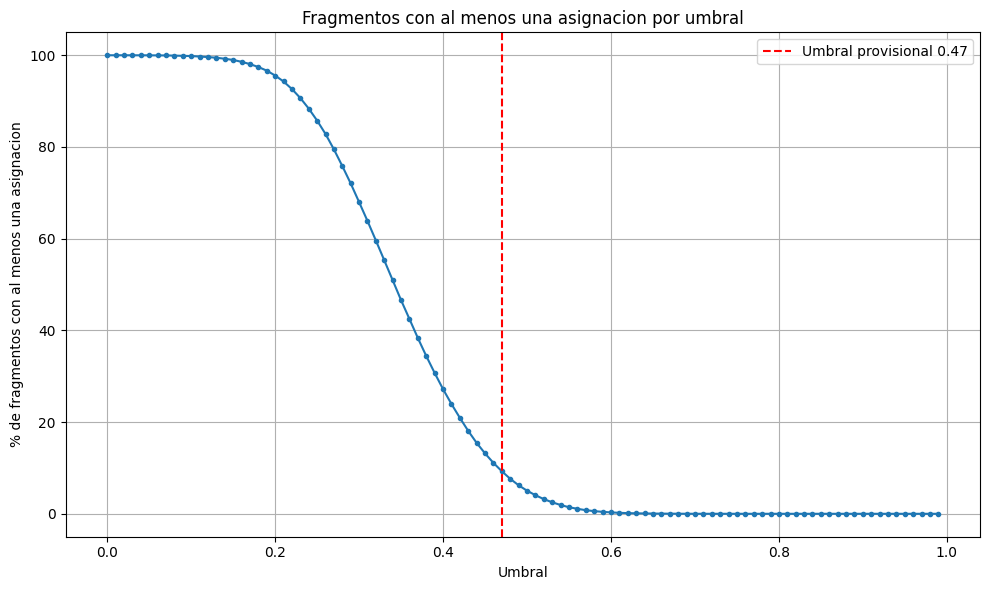

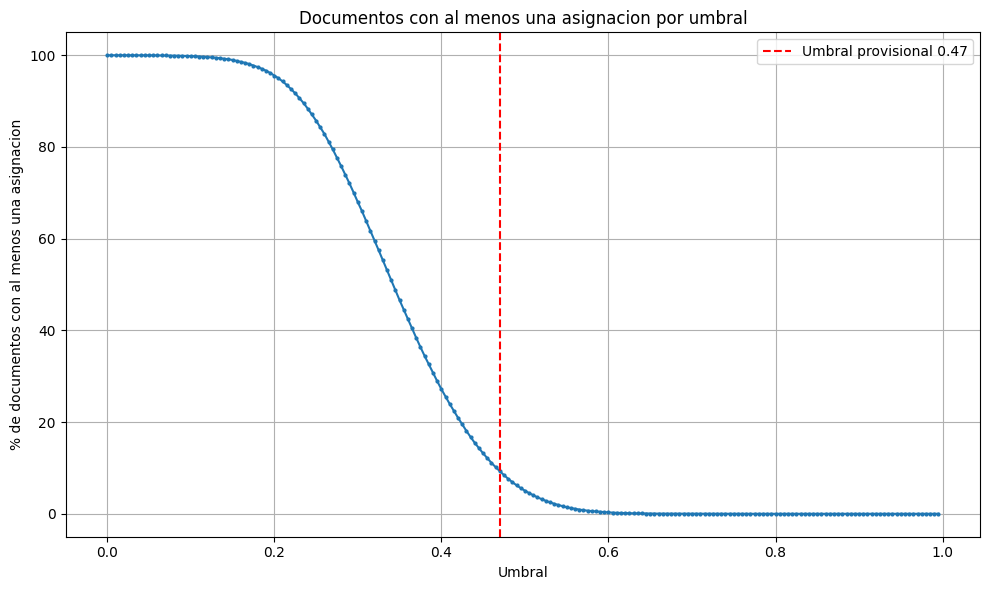

Descriptivos por subcategoria:
                               count    mean     std     min     25%     50%     75%     max
COMB_Capacidad_fisica       151424.0  0.1971  0.0809 -0.1128  0.1434  0.1942  0.2470  0.7172
COMB_Capacidad_psicologica  151424.0  0.2767  0.0923 -0.1064  0.2150  0.2740  0.3373  0.6658
COMB_Motivacion_automatica  151424.0  0.2572  0.0934 -0.1267  0.1948  0.2577  0.3207  0.6855
COMB_Motivacion_reflexiva   151424.0  0.2789  0.0994 -0.1112  0.2094  0.2748  0.3444  0.7345
COMB_Oportunidad_fisica     151424.0  0.2857  0.1104 -0.0951  0.2061  0.2810  0.3618  0.7275
COMB_Oportunidad_social     151424.0  0.2239  0.0950 -0.1332  0.1584  0.2218  0.2889  0.6014


In [11]:
# ============================================================
# CELL 9 — ESTADISTICOS Y CURVA DEL UMBRAL
# Equivalente a celdas 28-31 del paper
# ============================================================

subcats        = list(subcat_embeddings.keys())
# columnas de subcategorias en sim_df (excluyendo chunk_id, id_doc, texto_chunk)
subcat_cols_df = [c for c in sim_df.columns if c not in ['chunk_id', 'id_doc', 'texto_chunk']]

sim_temp = sim_df[subcat_cols_df].astype(float)

# --- Asignaciones por subcategoria con umbral provisional (Karen cell 28) ---
asign_por_subcat = (sim_temp >= UMBRAL_PROVISIONAL).sum().sort_values(ascending=False)
print('Asignaciones por subcategoria:')
print(asign_por_subcat.to_string())
print()

# --- Curva: % chunks con al menos una asignacion por umbral (Karen cell 29) ---
import numpy as np
umbrales = np.arange(0, 1, 0.01)
chunks_con_asignacion = [
    (sim_temp >= u).any(axis=1).sum() / len(sim_temp) * 100
    for u in umbrales
]

plt.figure(figsize=(10, 6))
plt.plot(umbrales, chunks_con_asignacion, marker='o', markersize=3)
plt.axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
            label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
plt.xlabel('Umbral')
plt.ylabel('% de fragmentos con al menos una asignacion')
plt.title('Fragmentos con al menos una asignacion por umbral')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_curva_umbral_chunks.png', dpi=150)
plt.show()

# --- Curva: % docs con al menos una asignacion (Karen cell 30) ---
subcat_cols_doc = [c for c in sim_docs_df_merged.columns
                   if c not in ['id_doc', 'texto_chunk']]
sim_temp_doc = sim_docs_df_merged[subcat_cols_doc].astype(float)

umbrales2 = np.arange(0, 1, 0.005)
docs_con_asignacion = [
    (sim_temp_doc >= u).any(axis=1).sum() / len(sim_temp_doc) * 100
    for u in umbrales2
]

plt.figure(figsize=(10, 6))
plt.plot(umbrales2, docs_con_asignacion, marker='o', markersize=2)
plt.axvline(UMBRAL_PROVISIONAL, color='red', linestyle='--',
            label=f'Umbral provisional {UMBRAL_PROVISIONAL}')
plt.xlabel('Umbral')
plt.ylabel('% de documentos con al menos una asignacion')
plt.title('Documentos con al menos una asignacion por umbral')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_curva_umbral_docs.png', dpi=150)
plt.show()

# --- Descriptivos por subcategoria (Karen cell 32-33) ---
descriptivos = sim_temp.describe().T.round(4)
print('Descriptivos por subcategoria:')
print(descriptivos.to_string())

## 10 · Asignación con umbral provisional
Replica exacta de `uss.asignar_categorias()`:  
itera fila por fila, añade todas las subcategorías que superan el umbral  
como lista de tuplas `(subcategoria, score)` en el orden de las columnas.  
Si ninguna supera: `[('ninguna', 0)]`.

In [12]:
# ============================================================
# CELL 10 — ASIGNACION CON UMBRAL
# Replica exacta de uss.asignar_categorias(df, umbral)
# ============================================================

def asignar_categorias(df, umbral=0.30):
    """
    Replica exacta de uss.asignar_categorias().
    Itera fila por fila. Excluye columnas chunk_id, id_doc, texto_chunk.
    Retorna lista de tuplas (subcategoria, score) — sin ordenar por score.
    Si ninguna supera: [('ninguna', 0)]
    """
    categorias_detectadas = []
    for _, fila in df.iterrows():
        cats = []
        for col in df.columns:
            if col not in ['chunk_id', 'id_doc', 'texto_chunk']:
                if fila[col] >= umbral:
                    cats.append((col, fila[col]))
        categorias_detectadas.append(cats if cats else [('ninguna', 0)])

    df = df.copy()
    df['categorias_detectadas'] = categorias_detectadas
    return df


print(f'Asignando categorias con umbral provisional {UMBRAL_PROVISIONAL}...')
print('(iteracion fila a fila — puede tardar unos minutos con 151K tweets)')
resultado = asignar_categorias(sim_df, umbral=UMBRAL_PROVISIONAL)

# Etiqueta binaria — identica a Karen:
# resultado['etiqueta_ciencia'] = resultado['categorias_detectadas'].apply(
#     lambda x: 1 if x[0][0] != 'ninguna' else 0)
resultado['etiqueta_comb'] = resultado['categorias_detectadas'].apply(
    lambda x: 1 if x[0][0] != 'ninguna' else 0
)

resultado.head(3)

Asignando categorias con umbral provisional 0.47...
(iteracion fila a fila — puede tardar unos minutos con 151K tweets)


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social,categorias_detectadas,etiqueta_comb
0,1_1,1,VDEO Reos que no están contagiados con COVID19...,0.208963,0.282247,0.272715,0.347574,0.376211,0.192192,"[(ninguna, 0)]",0
1,2_1,2,ya se enteraron de la muerte supestamente por ...,0.202656,0.380844,0.289088,0.285999,0.269525,0.240162,"[(ninguna, 0)]",0
2,3_1,3,El calvario de una familia en Cali por su mamá...,0.172547,0.259670,0.287314,0.214912,0.301384,0.376552,"[(ninguna, 0)]",0


## 11 · Estadísticos del resultado

In [13]:
# ============================================================
# CELL 11 — ESTADISTICOS DEL RESULTADO
# Equivalente a celdas 26-27 del paper
# ============================================================

# Distribucion de categorias_detectadas (Karen cell 26)
print('Top combinaciones de categorias_detectadas:')
print(resultado['categorias_detectadas'].apply(str).value_counts().head(15).to_string())
print()

# Docs con al menos una categoria (Karen cell 27)
docs_con_categoria = resultado[
    resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')
]['id_doc'].nunique()
print(f'Tweets con al menos una categoria del COM-B : {docs_con_categoria:,}')
pct = docs_con_categoria / len(resultado) * 100
print(f'Porcentaje                                 : {pct:.1f}%')

Top combinaciones de categorias_detectadas:
categorias_detectadas
[('ninguna', 0)]                                                                                        137371
[('COMB_Capacidad_psicologica', 0.5208456516265869)]                                                         2
[('COMB_Motivacion_reflexiva', 0.49809449911117554)]                                                         2
[('COMB_Motivacion_reflexiva', 0.47956955432891846)]                                                         2
[('COMB_Oportunidad_fisica', 0.5039920806884766)]                                                            2
[('COMB_Oportunidad_fisica', 0.4910518527030945)]                                                            2
[('COMB_Motivacion_reflexiva', 0.4750462472438812)]                                                          2
[('COMB_Oportunidad_fisica', 0.47928309440612793)]                                                           2
[('COMB_Motivacion_reflexiva', 0.4906166493892

## 12 · Guardar resultados finales

In [14]:
# ============================================================
# CELL 12 — GUARDAR RESULTADOS FINALES
# Equivalente a:
#   resultado.to_excel('chunks_etiquetados_binario.xlsx')
#   resultado_ciencia.to_excel('ciencia_chunks.xlsx')
# ============================================================

# Serializar categorias_detectadas a string para parquet
resultado_save = resultado.copy()
resultado_save['categorias_detectadas'] = resultado_save['categorias_detectadas'].apply(str)

# Todos los tweets etiquetados (binario)
resultado_save.to_parquet(DATA_PROCESSED / 'comb_etiquetados_binario.parquet', index=False)
resultado_save.to_excel(DATA_PROCESSED / 'chunks_etiquetados_binario.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] tweets_etiquetados_binario  ({len(resultado_save):,} filas)')

# Solo tweets del COM-B (equivalente a resultado_ciencia del paper)
resultado_comb = resultado[
    resultado['categorias_detectadas'].apply(lambda x: x[0][0] != 'ninguna')
].copy()
resultado_comb_save = resultado_comb.copy()
resultado_comb_save['categorias_detectadas'] = resultado_comb_save['categorias_detectadas'].apply(str)

resultado_comb_save.to_parquet(DATA_PROCESSED / 'comb_tweets.parquet', index=False)
resultado_comb_save.to_excel(DATA_PROCESSED / 'comb_chunks.xlsx', index=False, engine='openpyxl')
print(f'[GUARDADO] comb_tweets                ({len(resultado_comb_save):,} filas)')

print()
print(f'  Total tweets         : {len(resultado):,}')
print(f'  Tweets con COM-B     : {len(resultado_comb):,} ({len(resultado_comb)/len(resultado)*100:.1f}%)')
print(f'  Umbral usado (prov.) : {UMBRAL_PROVISIONAL}')
print()
print('Notebook 03 completado.')
print('Siguiente -> 04_seleccion_umbral.ipynb')

[GUARDADO] tweets_etiquetados_binario  (151,424 filas)
[GUARDADO] comb_tweets                (14,053 filas)

  Total tweets         : 151,424
  Tweets con COM-B     : 14,053 (9.3%)
  Umbral usado (prov.) : 0.47

Notebook 03 completado.
Siguiente -> 04_seleccion_umbral.ipynb
